<a href="https://colab.research.google.com/github/danielandreawilson-tech/Bay_area_employment_trends_final-/blob/main/notebooks/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# import os
# import pandas as pd
# from pathlib import Path
# project_root = Path("/content/drive/MyDrive/Urban informatics /employment_trends") # we create a project root so to build a relative path
# os.chdir(project_root) # changes the directory to the desired path above so to use relative paths
# double u get share the link or put it into github


In [3]:
!git clone https://github.com/danielandreawilson-tech/Bay_area_employment_trends_final-.git

Cloning into 'Bay_area_employment_trends_final-'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 21 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 8.76 KiB | 8.76 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [1]:
from pathlib import Path
import os
import sys

# project root = parent folder of the notebook folder
PROJECT_ROOT = Path.cwd().parent

# move working directory to project root
os.chdir(PROJECT_ROOT)

# define project folders
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
VIS_DIR = PROJECT_ROOT / "visualizations"
SRC_DIR = PROJECT_ROOT / "src"

# allow imports from src/
sys.path.append(str(SRC_DIR))

# check path
print("Project root:", PROJECT_ROOT)
print("Current working directory:", os.getcwd())

Project root: /
Current working directory: /


In [3]:
print(os.getcwd()) # check if the path worked

/content/drive/.shortcut-targets-by-id/1ElrdEuMH-7xX8rtDu7wdFUqRA3pfNQLV/Urban Informatics Group Project


In [4]:
raw_path = Path("/content/drive/MyDrive/Urban informatics /employment_trends/data/raw/csv/RawData.csv") # we call our employment csv so to start working with our data
raw_df = pd.read_csv(raw_path)

In [5]:
raw_df.columns #show columns to check for formatting

Index(['periodicity', 'periodicity_label.value', 'seasonadj',
       'seasonadj_label.value', 'geo_level', 'geo_level_label.value',
       'geography', 'geography_label.value', 'ind_level', 'industry',
       'industry_label.value', 'ownercode', 'ownercode_label.value', 'sex',
       'sex_label.value', 'agegrp', 'agegrp_label.value', 'race',
       'race_label.value', 'ethnicity', 'ethnicity_label.value', 'education',
       'education_label.value', 'firmage', 'firmage_label.value', 'firmsize',
       'firmsize_label.value', 'year', 'quarter', 'agg_level', 'EmpS',
       'sEmpS'],
      dtype='object')

In [6]:
pre_cleaned_df = raw_df.copy()

# standardize column names to snake_case
pre_cleaned_df.columns = raw_df.columns.str.lower().str.replace('.', '_', regex=False).str.replace(' ', '_', regex=False)

pre_cleaned_df.columns


Index(['periodicity', 'periodicity_label_value', 'seasonadj',
       'seasonadj_label_value', 'geo_level', 'geo_level_label_value',
       'geography', 'geography_label_value', 'ind_level', 'industry',
       'industry_label_value', 'ownercode', 'ownercode_label_value', 'sex',
       'sex_label_value', 'agegrp', 'agegrp_label_value', 'race',
       'race_label_value', 'ethnicity', 'ethnicity_label_value', 'education',
       'education_label_value', 'firmage', 'firmage_label_value', 'firmsize',
       'firmsize_label_value', 'year', 'quarter', 'agg_level', 'emps',
       'semps'],
      dtype='object')

In [7]:
# drop columns that are not useful for our analysis
pre_cleaned_df = pre_cleaned_df.drop(['periodicity', 'periodicity_label_value', 'agegrp', 'agegrp_label_value', 'seasonadj',	'seasonadj_label_value', 'sex', 'sex_label_value', 'education',
       'education_label_value', 'firmage', 'firmage_label_value','quarter'], axis=1)

pre_cleaned_df.head(5)

,geo_level,geo_level_label_value,geography,geography_label_value,ind_level,industry,industry_label_value,ownercode,ownercode_label_value,race,race_label_value,ethnicity,ethnicity_label_value,firmsize,firmsize_label_value,year,agg_level,emps,semps
0,S,States,6,California,A,00,All NAICS Sectors,A05,All Private,A0,All Races,A0,All Ethnicities,0,All Firm Sizes,2018,1057,12963342.0,1
1,S,States,6,California,A,00,All NAICS Sectors,A05,All Private,A0,All Races,A1,Not Hispanic or Latino,0,All Firm Sizes,2018,1065,8468553.0,1
2,S,States,6,California,A,00,All NAICS Sectors,A05,All Private,A0,All Races,A2,Hispanic or Latino,0,All Firm Sizes,2018,1065,4494789.0,1
3,S,States,6,California,A,00,All NAICS Sectors,A05,All Private,A1,White Alone,A0,All Ethnicities,0,All Firm Sizes,2018,1061,9153163.0,1
4,S,States,6,California,A,00,All NAICS Sectors,A05,All Private,A1,White Alone,A1,Not Hispanic or Latino,0,All Firm Sizes,2018,1069,5180850.0,1


In [8]:
# check for data types so to avoid calculation issues
print(pre_cleaned_df.dtypes)

geo_level                 object
geo_level_label_value     object
geography                  int64
geography_label_value     object
ind_level                 object
industry                  object
industry_label_value      object
ownercode                 object
ownercode_label_value     object
race                      object
race_label_value          object
ethnicity                 object
ethnicity_label_value     object
firmsize                   int64
firmsize_label_value      object
year                       int64
agg_level                  int64
emps                     float64
semps                      int64
dtype: object


In [9]:
# fixing data types just to keep consistency throughout datasets this is not essential in this case (geography, year, earnings, n_employed)
pre_cleaned_df['geography'] = pre_cleaned_df['geography'].astype(str)
pre_cleaned_df['year_pd'] = pd.to_datetime(pre_cleaned_df['year'], format="%Y", errors="coerce") # errors="coerce" brings NaN if missing
pre_cleaned_df['n_employed'] = pd.to_numeric(pre_cleaned_df['emps'], errors='coerce').astype("Int64")

In [10]:
print(pre_cleaned_df.dtypes) #sanity check that our change worked

geo_level                        object
geo_level_label_value            object
geography                        object
geography_label_value            object
ind_level                        object
industry                         object
industry_label_value             object
ownercode                        object
ownercode_label_value            object
race                             object
race_label_value                 object
ethnicity                        object
ethnicity_label_value            object
firmsize                          int64
firmsize_label_value             object
year                              int64
agg_level                         int64
emps                            float64
semps                             int64
year_pd                  datetime64[ns]
n_employed                        Int64
dtype: object


In [11]:
# we drop extra columns after fixing data types since we will not use these
pre_cleaned_df = pre_cleaned_df.drop(['emps', 'year','semps'], axis=1)

In [12]:
print(pre_cleaned_df.dtypes)

geo_level                        object
geo_level_label_value            object
geography                        object
geography_label_value            object
ind_level                        object
industry                         object
industry_label_value             object
ownercode                        object
ownercode_label_value            object
race                             object
race_label_value                 object
ethnicity                        object
ethnicity_label_value            object
firmsize                          int64
firmsize_label_value             object
agg_level                         int64
year_pd                  datetime64[ns]
n_employed                        Int64
dtype: object


In [13]:
# check for duplicates and if all rows are unique so to avoid double counting
print(pre_cleaned_df.duplicated().sum())

0


In [14]:
# check for any missing values so to avoid any bias in the results
pre_cleaned_df.isnull().sum().sort_values(ascending=False)

,0
n_employed,13338
geo_level,0
geo_level_label_value,0
geography,0
ind_level,0
geography_label_value,0
industry_label_value,0
ownercode,0
ownercode_label_value,0
industry,0


In [15]:
# there are some missing values, we want to check how big of an issue this is
pre_cleaned_df[['n_employed']].isnull().mean()


,0
n_employed,0.078181


In [16]:
# we decide not to drop these at the moment but they are a small percentage of all

In [17]:
# let's check what counties are included. We have pre filtered these while downloading the data so they should be all we want (9 Bay Area counties + California )
pre_cleaned_df["geography_label_value"].unique()

array(['California', 'Alameda, CA', 'Contra Costa, CA', 'Marin, CA',
       'Napa, CA', 'San Francisco, CA', 'San Mateo, CA',
       'Santa Clara, CA', 'Solano, CA', 'Sonoma, CA'], dtype=object)

In [18]:
# we want to keep only bay area counties so we make a list of these and then we ask to keep only the rows that have these counties (remove California)
bay_area_counties = [
    "Alameda, CA",
    "Contra Costa, CA",
    "Marin, CA",
    "Napa, CA",
    "San Francisco, CA",
    "San Mateo, CA",
    "Santa Clara, CA",
    "Solano, CA",
    "Sonoma, CA"
]

pre_cleaned_df = pre_cleaned_df[
    pre_cleaned_df["geography_label_value"].isin(bay_area_counties)
].copy()

In [19]:
# check whether this worked
pre_cleaned_df["geography_label_value"].unique()

array(['Alameda, CA', 'Contra Costa, CA', 'Marin, CA', 'Napa, CA',
       'San Francisco, CA', 'San Mateo, CA', 'Santa Clara, CA',
       'Solano, CA', 'Sonoma, CA'], dtype=object)

In [20]:
# we have decided to remove California aggregate observations

In [21]:
pre_cleaned_df.head()

,geo_level,geo_level_label_value,geography,geography_label_value,ind_level,industry,industry_label_value,ownercode,ownercode_label_value,race,race_label_value,ethnicity,ethnicity_label_value,firmsize,firmsize_label_value,agg_level,year_pd,n_employed
17829,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A0,All Races,A0,All Ethnicities,0,All Firm Sizes,4129,2018-01-01,624186
17830,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A0,All Races,A1,Not Hispanic or Latino,0,All Firm Sizes,4137,2018-01-01,472770
17831,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A0,All Races,A2,Hispanic or Latino,0,All Firm Sizes,4137,2018-01-01,151416
17832,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A1,White Alone,A0,All Ethnicities,0,All Firm Sizes,4133,2018-01-01,360841
17833,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A1,White Alone,A1,Not Hispanic or Latino,0,All Firm Sizes,4141,2018-01-01,233414


In [22]:
### SUMMARY STATISTICS
pre_cleaned_df[["n_employed"]].describe()

,n_employed
count,139496.0
mean,2523.293593
std,17809.247923
min,0.0
25%,14.0
50%,90.0
75%,664.0
max,963429.0


In [23]:
# min n_employed is 0 we know that we have missing values here, we will deal with those later in the code

In [24]:
# we now want to save this into our processed folder
pre_cleaned_df.to_csv("data/processed/bay_area_cleaned_df.csv", index=False)

In [25]:
# let's open the newly created cleaned and filtered dataframe and we will call this county_df from now on
county_df = pd.read_csv("data/processed/bay_area_cleaned_df.csv")

In [26]:
# let's check if the 0 all firm sizes is there, we will want to filter only for all in this phase.
county_df["firmsize"].unique()

array([0, 1, 2, 3, 4, 5])

In [27]:
# let's check if the 00 all industries is there, we will want to filter only for all since Vital Signs has already done this type of analysis.
county_df["industry"].unique()


array(['00', '11', '21', '22', '23', '31-33', '42', '44-45', '48-49',
       '51', '52', '53', '54', '55', '56', '61', '62', '71', '72', '81',
       '92'], dtype=object)

In [28]:
# let's check that all races are included A0, we want to filter for all races only in the initial part of the analysis
county_df["race"].unique()



array(['A0', 'A1', 'A2', 'A3', 'A4', 'A5', 'A7'], dtype=object)

In [29]:
# let's check that all ethnicities (A0) are included
county_df["ethnicity"].unique()

array(['A0', 'A1', 'A2'], dtype=object)

In [30]:
##### ANALYSIS SECTION 1 ######

# COUNTY TOTALS #

# RECOVERY INDEX ALL FIRM TYPES FOR GENERAL POPULATION

#let's filter for total employment - all industries - all ethnicities - all ownercodes  - all races to calculate Total Recovery index by county and by firmsize
df_totals = county_df[
    (county_df["industry"] == "00") &
    (county_df["race"] == "A0") &
    (county_df["ethnicity"] == "A0") &
    (county_df["ownercode"] == "A05")

].copy()



In [31]:
# drop n_employed missing values before calculating recovery index to avoid inf
df_totals = df_totals.dropna(subset=["n_employed"])

In [32]:
# year_pd to datetime (we don't need this but it might be useful in the future)
df_totals["year_pd"] = pd.to_datetime(df_totals["year_pd"])

In [33]:
df_totals.head()

,geo_level,geo_level_label_value,geography,geography_label_value,ind_level,industry,industry_label_value,ownercode,ownercode_label_value,race,race_label_value,ethnicity,ethnicity_label_value,firmsize,firmsize_label_value,agg_level,year_pd,n_employed
0,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A0,All Races,A0,All Ethnicities,0,All Firm Sizes,4129,2018-01-01,624186.0
21,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A0,All Races,A0,All Ethnicities,1,0-19 Employees,4257,2018-01-01,121183.0
42,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A0,All Races,A0,All Ethnicities,2,20-49 Employees,4257,2018-01-01,61141.0
63,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A0,All Races,A0,All Ethnicities,3,50-249 Employees,4257,2018-01-01,99856.0
84,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A0,All Races,A0,All Ethnicities,4,250-499 Employees,4257,2018-01-01,33673.0


In [34]:
# let's group by n_employed, year and county so to calculate baseline
df_totals = df_totals.groupby(
    ["geography_label_value", "year_pd","firmsize","firmsize_label_value"]
)["n_employed"].sum().reset_index()

In [35]:
df_totals.head()

,geography_label_value,year_pd,firmsize,firmsize_label_value,n_employed
0,"Alameda, CA",2018-01-01,0,All Firm Sizes,624186.0
1,"Alameda, CA",2018-01-01,1,0-19 Employees,121183.0
2,"Alameda, CA",2018-01-01,2,20-49 Employees,61141.0
3,"Alameda, CA",2018-01-01,3,50-249 Employees,99856.0
4,"Alameda, CA",2018-01-01,4,250-499 Employees,33673.0


In [36]:
!ls data/functions

data_cleaning_tools.py	helper.py  __pycache__


In [37]:
######## HELPER CALL ######
from data.functions.data_cleaning_tools import (
    add_baseline, # function 1
    add_recovery_index, # function 2
    plot_trends, # function 3
    map_race_population, #function 4
    plot_jobs_per_capita_by_race, #function 5
    map_ethnicity_population, #function 6
    plot_recovery_trends #fuction 7
)

In [38]:
# let's apply our baseline employment function (2019) by county which will be necessary to build our recovery index. See helper file for function
df_totals = add_baseline(
    df_totals,
    value_col="n_employed",
    baseline_year=2019,
    group_cols=["geography_label_value", "firmsize"]
)

In [39]:
# check if we have any missing values as a sanity check
df_totals.isnull().sum().sort_values(ascending=False)

,0
geography_label_value,0
year_pd,0
firmsize,0
firmsize_label_value,0
n_employed,0
baseline_emp,0


In [40]:
# calculate recovery index on df_totals
df_totals = add_recovery_index(
    df_totals,
    current_col="n_employed",
    baseline_col="baseline_emp",
    recovery_col="recovery_index_all"
)

In [41]:
# calculate recovery index (empoyed at year t / employed at year 2019)
#df_totals["recovery_index_all"] = (
#    df_totals["n_employed"] / df_totals["baseline_emp"]
#) * 100

In [42]:
df_totals.head(10)

,geography_label_value,year_pd,firmsize,firmsize_label_value,n_employed,baseline_emp,recovery_index_all
0,"Alameda, CA",2018-01-01,0,All Firm Sizes,624186.0,633617.0,98.511561
1,"Alameda, CA",2018-01-01,1,0-19 Employees,121183.0,124883.0,97.037227
2,"Alameda, CA",2018-01-01,2,20-49 Employees,61141.0,63697.0,95.987252
3,"Alameda, CA",2018-01-01,3,50-249 Employees,99856.0,98282.0,101.601514
4,"Alameda, CA",2018-01-01,4,250-499 Employees,33673.0,35988.0,93.567300
5,"Alameda, CA",2018-01-01,5,500+ Employees,308332.0,310767.0,99.216455
6,"Alameda, CA",2019-01-01,0,All Firm Sizes,633617.0,633617.0,100.000000
7,"Alameda, CA",2019-01-01,1,0-19 Employees,124883.0,124883.0,100.000000
8,"Alameda, CA",2019-01-01,2,20-49 Employees,63697.0,63697.0,100.000000
9,"Alameda, CA",2019-01-01,3,50-249 Employees,98282.0,98282.0,100.000000


In [43]:
# clean df_totals as county only names (e.g. Alameda, CA to Alameda) this will be our formatting for now on across all datasets
df_totals["county"] = df_totals["geography_label_value"].str.replace(", CA", "", regex=False)

In [44]:
df_totals.head()

,geography_label_value,year_pd,firmsize,firmsize_label_value,n_employed,baseline_emp,recovery_index_all,county
0,"Alameda, CA",2018-01-01,0,All Firm Sizes,624186.0,633617.0,98.511561,Alameda
1,"Alameda, CA",2018-01-01,1,0-19 Employees,121183.0,124883.0,97.037227,Alameda
2,"Alameda, CA",2018-01-01,2,20-49 Employees,61141.0,63697.0,95.987252,Alameda
3,"Alameda, CA",2018-01-01,3,50-249 Employees,99856.0,98282.0,101.601514,Alameda
4,"Alameda, CA",2018-01-01,4,250-499 Employees,33673.0,35988.0,93.567300,Alameda


In [45]:
# we drop extra column after fixing column names for county since it is not necessary
df_totals = df_totals.drop(['geography_label_value'], axis=1)

In [46]:
df_totals.head()

,year_pd,firmsize,firmsize_label_value,n_employed,baseline_emp,recovery_index_all,county
0,2018-01-01,0,All Firm Sizes,624186.0,633617.0,98.511561,Alameda
1,2018-01-01,1,0-19 Employees,121183.0,124883.0,97.037227,Alameda
2,2018-01-01,2,20-49 Employees,61141.0,63697.0,95.987252,Alameda
3,2018-01-01,3,50-249 Employees,99856.0,98282.0,101.601514,Alameda
4,2018-01-01,4,250-499 Employees,33673.0,35988.0,93.567300,Alameda


In [47]:
# Highlight selected counties

fig = plot_recovery_trends(
    df=df_totals[df_totals["firmsize"] == 0],
    x_col="year_pd",
    y_col="recovery_index_all",
    group_col="county",
    title="Recovery Index by County (Base Year = 2019)",
    ylabel="Recovery Index (2019 = 100)",
    save_path="visualizations/recovery_index_county.html"
)

# Highlight selected counties
start_counties = ["Alameda", "San Francisco"] #pre-select a couple of counties for easier readability
for trace in fig.data:
    if trace.name not in start_counties:
        trace.visible = "legendonly" #allow for still toggling through specific counties

fig.show()

In [48]:
firm_size_trends = (
    df_totals[df_totals["firmsize"] != 0]
    .groupby(["year_pd", "firmsize","firmsize_label_value"], as_index=False)
    .agg({
        "n_employed": "sum", # we need to add the number of employed for each county
        "baseline_emp": "sum" # we need to also add the baseline employment for each county
    })

)



In [49]:
#applies the recovery index function calculated earlier
firm_size_trends = add_recovery_index(
    firm_size_trends,
    current_col="n_employed",
    baseline_col="baseline_emp",
    recovery_col="recovery_index_all"
)

In [50]:

fig = plot_recovery_trends(
    df=firm_size_trends,
    x_col="year_pd",
    y_col="recovery_index_all",
    group_col="firmsize_label_value",
    title="Recovery Index by Firm Size (Base Year = 2019)",
    ylabel="Recovery Index (2019 = 100)",
    save_path="visualizations/recovery_index_firm_size.html",
)

fig.show()

In [51]:
#in order to create a job per capita ratio we need to import ACS population data
# we first check for the column names as well, we only want to pick the absolute population values

test_acs = pd.read_csv(
    "data/raw/acs/ACSDT5Y2018.B03002-Data.csv",
    skiprows=1
)

test_acs.columns.tolist()


['Geography',
 'Geographic Area Name',
 'Estimate!!Total',
 'Margin of Error!!Total',
 'Estimate!!Total!!Not Hispanic or Latino',
 'Margin of Error!!Total!!Not Hispanic or Latino',
 'Estimate!!Total!!Not Hispanic or Latino!!White alone',
 'Margin of Error!!Total!!Not Hispanic or Latino!!White alone',
 'Estimate!!Total!!Not Hispanic or Latino!!Black or African American alone',
 'Margin of Error!!Total!!Not Hispanic or Latino!!Black or African American alone',
 'Estimate!!Total!!Not Hispanic or Latino!!American Indian and Alaska Native alone',
 'Margin of Error!!Total!!Not Hispanic or Latino!!American Indian and Alaska Native alone',
 'Estimate!!Total!!Not Hispanic or Latino!!Asian alone',
 'Margin of Error!!Total!!Not Hispanic or Latino!!Asian alone',
 'Estimate!!Total!!Not Hispanic or Latino!!Native Hawaiian and Other Pacific Islander alone',
 'Margin of Error!!Total!!Not Hispanic or Latino!!Native Hawaiian and Other Pacific Islander alone',
 'Estimate!!Total!!Not Hispanic or Latino!!S

In [52]:
#cleans by keeping only the columns we need
acs = test_acs[[
    "Geographic Area Name",
    "Estimate!!Total",
    "Estimate!!Total!!Not Hispanic or Latino!!White alone",
    "Estimate!!Total!!Not Hispanic or Latino!!Black or African American alone",
    "Estimate!!Total!!Not Hispanic or Latino!!American Indian and Alaska Native alone",
    "Estimate!!Total!!Not Hispanic or Latino!!Asian alone",
    "Estimate!!Total!!Hispanic or Latino"
]].copy()

In [53]:
# change column names in a way that we can easily read it and interpret
acs = acs.rename(columns={
    "Geographic Area Name": "county",
    "Estimate!!Total": "pop_total",
    "Estimate!!Total!!Not Hispanic or Latino!!White alone": "pop_white",
    "Estimate!!Total!!Not Hispanic or Latino!!Black or African American alone": "pop_black",
    "Estimate!!Total!!Not Hispanic or Latino!!American Indian and Alaska Native alone": "pop_native",
    "Estimate!!Total!!Not Hispanic or Latino!!Asian alone": "pop_asian",
    "Estimate!!Total!!Hispanic or Latino": "pop_hispanic"
})

acs.head()

,county,pop_total,pop_white,pop_black,pop_native,pop_asian,pop_hispanic
0,"Alameda County, California",1643700,523391,172329,5288,483067,369061
1,"Contra Costa County, California",1133247,502951,93683,2376,182135,288101
2,"Marin County, California",260295,185809,5597,435,14815,41335
3,"Napa County, California",140530,74159,2764,326,11210,47687
4,"San Francisco County, California",870044,353670,43619,1363,294846,132651


In [54]:
# this is just one year (2018), we add the year so that we can later group these by year
acs["year"] = 2018

In [55]:
# clean the county names so that they match our other dataframes's format
acs["county_clean"] = (acs["county"].str.replace(" County, California", "", regex=False))
# + ", CA")


In [56]:
# we drop extra column after fixing column names for county
acs = acs.drop(['county'], axis=1)

In [57]:
acs.head()

,pop_total,pop_white,pop_black,pop_native,pop_asian,pop_hispanic,year,county_clean
0,1643700,523391,172329,5288,483067,369061,2018,Alameda
1,1133247,502951,93683,2376,182135,288101,2018,Contra Costa
2,260295,185809,5597,435,14815,41335,2018,Marin
3,140530,74159,2764,326,11210,47687,2018,Napa
4,870044,353670,43619,1363,294846,132651,2018,San Francisco


In [58]:
# for safety we convert to numeric (function)
for col in ["pop_total", "pop_white", "pop_black", "pop_native", "pop_asian", "pop_hispanic"]:
    acs[col] = pd.to_numeric(acs[col], errors="coerce")

In [59]:
print(acs.dtypes)

pop_total        int64
pop_white        int64
pop_black        int64
pop_native       int64
pop_asian        int64
pop_hispanic     int64
year             int64
county_clean    object
dtype: object


In [60]:
print(acs.head())

   pop_total  pop_white  pop_black  pop_native  pop_asian  pop_hispanic  year  \
0    1643700     523391     172329        5288     483067        369061  2018   
1    1133247     502951      93683        2376     182135        288101  2018   
2     260295     185809       5597         435      14815         41335  2018   
3     140530      74159       2764         326      11210         47687  2018   
4     870044     353670      43619        1363     294846        132651  2018   

    county_clean  
0        Alameda  
1   Contra Costa  
2          Marin  
3           Napa  
4  San Francisco  


In [61]:
acs_2018 = acs[[
    "county_clean",
    "pop_total",
    "pop_white",
    "pop_black",
    "pop_native",
    "pop_asian",
    "pop_hispanic",
    "year"
]].copy()

In [62]:
acs_2018.head()

,county_clean,pop_total,pop_white,pop_black,pop_native,pop_asian,pop_hispanic,year
0,Alameda,1643700,523391,172329,5288,483067,369061,2018
1,Contra Costa,1133247,502951,93683,2376,182135,288101,2018
2,Marin,260295,185809,5597,435,14815,41335,2018
3,Napa,140530,74159,2764,326,11210,47687,2018
4,San Francisco,870044,353670,43619,1363,294846,132651,2018


In [63]:
# this seemed to have worked for 2018, let's repeat for the remaining years so that then we can merge all these together in one single ACS df
acs_folder = Path("data/raw/acs")
years = [2019, 2020, 2021, 2022, 2023, 2024]

acs_list = []

for year in years:
    file_path = acs_folder / f"ACSDT5Y{year}.B03002-Data.csv"

    df = pd.read_csv(file_path, skiprows=1)

    df = df[[
        "Geographic Area Name",
        "Estimate!!Total:",
        "Estimate!!Total:!!Not Hispanic or Latino:!!White alone",
        "Estimate!!Total:!!Not Hispanic or Latino:!!Black or African American alone",
        "Estimate!!Total:!!Not Hispanic or Latino:!!American Indian and Alaska Native alone",
        "Estimate!!Total:!!Not Hispanic or Latino:!!Asian alone",
        "Estimate!!Total:!!Hispanic or Latino:"
    ]].copy()

    df = df.rename(columns={
        "Geographic Area Name": "county",
        "Estimate!!Total:": "pop_total",
        "Estimate!!Total:!!Not Hispanic or Latino:!!White alone": "pop_white",
        "Estimate!!Total:!!Not Hispanic or Latino:!!Black or African American alone": "pop_black",
        "Estimate!!Total:!!Not Hispanic or Latino:!!American Indian and Alaska Native alone": "pop_native",
        "Estimate!!Total:!!Not Hispanic or Latino:!!Asian alone": "pop_asian",
        "Estimate!!Total:!!Hispanic or Latino:": "pop_hispanic"
    })

    df["county_clean"] = df["county"].str.replace(" County, California", "", regex=False)
    df["year"] = year

    for col in ["pop_total", "pop_white", "pop_black", "pop_native", "pop_asian","pop_hispanic"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    acs_list.append(df)

In [64]:
# merge these all together as mentioned above
acs_2019_2024 = pd.concat(acs_list, ignore_index=True)

acs_2019_2024.head()
acs_2019_2024.shape

(54, 9)

In [65]:
acs_all_df = pd.concat(
    [acs_2018, acs_2019_2024],
    ignore_index=True
)

In [66]:
# we drop extra column after fixing column names for county for the same reason stated previously
acs_all_df = acs_all_df.drop(['county'], axis=1)

In [67]:
acs_all_df.head(10)

,county_clean,pop_total,pop_white,pop_black,pop_native,pop_asian,pop_hispanic,year
0,Alameda,1643700,523391,172329,5288,483067,369061,2018
1,Contra Costa,1133247,502951,93683,2376,182135,288101,2018
2,Marin,260295,185809,5597,435,14815,41335,2018
3,Napa,140530,74159,2764,326,11210,47687,2018
4,San Francisco,870044,353670,43619,1363,294846,132651,2018
5,San Mateo,765935,303047,16838,1151,212474,189002,2018
6,Santa Clara,1922200,615912,45379,3003,685265,495455,2018
7,Solano,438530,168870,59500,1258,65994,114406,2018
8,Sonoma,501317,318237,7192,2068,19720,132985,2018
9,Alameda,1656754,520447,171168,5210,496006,371019,2019


In [68]:
# check if we have any missing values - sanity check
acs_all_df.isnull().sum().sort_values(ascending=False)

,0
county_clean,0
pop_total,0
pop_white,0
pop_black,0
pop_native,0
pop_asian,0
pop_hispanic,0
year,0


In [69]:
# convert years into datetime as our df_race uses datetime (not necessary but consistent with the rest of the code)
acs_all_df["year_pd"] = pd.to_datetime(acs_all_df["year"], format="%Y")

In [70]:
acs_all_df = acs_all_df.drop(columns=["year"])

In [71]:
acs_all_df.head()

,county_clean,pop_total,pop_white,pop_black,pop_native,pop_asian,pop_hispanic,year_pd
0,Alameda,1643700,523391,172329,5288,483067,369061,2018-01-01
1,Contra Costa,1133247,502951,93683,2376,182135,288101,2018-01-01
2,Marin,260295,185809,5597,435,14815,41335,2018-01-01
3,Napa,140530,74159,2764,326,11210,47687,2018-01-01
4,San Francisco,870044,353670,43619,1363,294846,132651,2018-01-01


In [72]:
print(acs_all_df.dtypes)

county_clean            object
pop_total                int64
pop_white                int64
pop_black                int64
pop_native               int64
pop_asian                int64
pop_hispanic             int64
year_pd         datetime64[ns]
dtype: object


In [73]:
acs_all_df = acs_all_df.rename(columns={"county_clean": "county"})

In [74]:
acs_all_df.columns

Index(['county', 'pop_total', 'pop_white', 'pop_black', 'pop_native',
       'pop_asian', 'pop_hispanic', 'year_pd'],
      dtype='object')

In [75]:
# filter for all firm size only
df_totals = df_totals[
    df_totals["firmsize"] == 0
].copy()


In [76]:
# let us now merge the two (employment & ACS data) so to compute later the Jobs per capita index
df_totals = df_totals.merge(
    acs_all_df,
    on=["county", "year_pd"],
    how="left"
)

df_totals.head()

,year_pd,firmsize,firmsize_label_value,n_employed,baseline_emp,recovery_index_all,county,pop_total,pop_white,pop_black,pop_native,pop_asian,pop_hispanic
0,2018-01-01,0,All Firm Sizes,624186.0,633617.0,98.511561,Alameda,1643700,523391,172329,5288,483067,369061
1,2019-01-01,0,All Firm Sizes,633617.0,633617.0,100.000000,Alameda,1656754,520447,171168,5210,496006,371019
2,2020-01-01,0,All Firm Sizes,592027.0,633617.0,93.436098,Alameda,1661584,508583,167316,4942,515105,369546
3,2021-01-01,0,All Firm Sizes,597503.0,633617.0,94.300342,Alameda,1673133,499730,166017,5248,524980,374542
4,2022-01-01,0,All Firm Sizes,628668.0,633617.0,99.218929,Alameda,1663823,487452,165390,4870,530999,369603


In [77]:
df_totals.isnull().sum().sort_values(ascending=False)

,0
year_pd,0
firmsize,0
firmsize_label_value,0
n_employed,0
baseline_emp,0
recovery_index_all,0
county,0
pop_total,0
pop_white,0
pop_black,0


In [78]:
# compute job per capita for df_totals
df_totals["jobs_per_capita"] = df_totals["n_employed"] / df_totals["pop_total"]

df_totals.head()

,year_pd,firmsize,firmsize_label_value,n_employed,baseline_emp,recovery_index_all,county,pop_total,pop_white,pop_black,pop_native,pop_asian,pop_hispanic,jobs_per_capita
0,2018-01-01,0,All Firm Sizes,624186.0,633617.0,98.511561,Alameda,1643700,523391,172329,5288,483067,369061,0.379744
1,2019-01-01,0,All Firm Sizes,633617.0,633617.0,100.000000,Alameda,1656754,520447,171168,5210,496006,371019,0.382445
2,2020-01-01,0,All Firm Sizes,592027.0,633617.0,93.436098,Alameda,1661584,508583,167316,4942,515105,369546,0.356303
3,2021-01-01,0,All Firm Sizes,597503.0,633617.0,94.300342,Alameda,1673133,499730,166017,5248,524980,374542,0.357116
4,2022-01-01,0,All Firm Sizes,628668.0,633617.0,99.218929,Alameda,1663823,487452,165390,4870,530999,369603,0.377845


In [79]:
df_totals["pop_total"].isna().sum()

np.int64(0)

In [80]:
# we now want to save this into our processed folder
df_totals.to_csv("data/processed/df_totals_cleaned.csv", index=False)

In [81]:
# let us first plot jobs_per_capita by county
df_totals_plot = df_totals.copy()

In [82]:
# we also want to check for population trends (not included in Story map)
pop_trends = df_totals[["county", "year_pd", "pop_total"]].drop_duplicates().copy()

pop_trends.head()

,county,year_pd,pop_total
0,Alameda,2018-01-01,1643700
1,Alameda,2019-01-01,1656754
2,Alameda,2020-01-01,1661584
3,Alameda,2021-01-01,1673133
4,Alameda,2022-01-01,1663823


In [83]:
df_totals.columns.tolist()

['year_pd',
 'firmsize',
 'firmsize_label_value',
 'n_employed',
 'baseline_emp',
 'recovery_index_all',
 'county',
 'pop_total',
 'pop_white',
 'pop_black',
 'pop_native',
 'pop_asian',
 'pop_hispanic',
 'jobs_per_capita']

In [84]:
# we want to plot jobs per capita by county, highlighting Alameda and San Francisco, we apply Function 3
fig = plot_trends(
    df=df_totals_plot,
    x_col="year_pd",
    y_col="jobs_per_capita",
    county_col="county",
    title="Jobs per Capita by County (Bay Area)",
    ylabel="Jobs per Capita (total jobs / total population)",
    save_path="visualizations/jobs_capita_county.png",
    figsize=(8, 6),
    legend_title="Counties:",
    y_min=0,
    start_groups=["Alameda", "San Francisco"]
)

fig.show()

In [85]:
# SECTION 3

######

# CHOROPLETH MAPS - let us import TIGERLINE shapefiles to create a map

######
import geopandas as gpd
gdf = gpd.read_file("data/raw/shapefiles/California counties")

In [86]:
##gdf.columns

In [87]:
gdf.head()

,Year,CountyName,COUNTY_FIP,DistrictCo,geometry
0,2023,Alameda,001,22,"MULTIPOLYGON (((-13577345.444 4504491.196, -13..."
1,2023,Alpine,003,2,"POLYGON ((-13312191.387 4680675.259, -13312135..."
2,2023,Amador,005,2,"POLYGON ((-13366398.979 4679185.227, -13366398..."
3,2023,Colusa,011,5,"POLYGON ((-13568735.664 4776807.645, -13568728..."
4,2023,El Dorado,017,16,"POLYGON ((-13347688.733 4712126.051, -13347699..."


In [88]:
# COUNTY TOTAL CHOROPLETH MAP
map_df = df_totals[df_totals["year_pd"].dt.year == 2024].copy() # for 2024, create a dataframe which is equal to total employments.

In [89]:
# we keep only the two columns of interest
map_df[["county", "recovery_index_all"]]

,county,recovery_index_all
6,Alameda,103.461397
13,Contra Costa,101.619699
20,Marin,100.878956
27,Napa,102.584404
34,San Francisco,96.572147
41,San Mateo,102.044642
48,Santa Clara,105.065318
55,Solano,103.061769
62,Sonoma,101.555955


In [90]:
# from the tiger line shapefiles we want to keep only the counties we are interested in
bay_counties = map_df["county"].unique().tolist()
bay_gdf = gdf[gdf["CountyName"].isin(bay_counties)].copy()

bay_gdf[["CountyName"]]

,CountyName
0,Alameda
21,San Francisco
26,Solano
27,Sonoma
36,Contra Costa
42,Marin
45,Napa
50,San Mateo
52,Santa Clara


In [91]:
# merge the shapefiles with the map_df so to connect the shapefiles with the results
bay_gdf = bay_gdf.merge(
    map_df[["county", "recovery_index_all"]],
    left_on="CountyName",
    right_on="county",
    how="left"
)

bay_gdf[["CountyName", "recovery_index_all"]]

,CountyName,recovery_index_all
0,Alameda,103.461397
1,San Francisco,96.572147
2,Solano,103.061769
3,Sonoma,101.555955
4,Contra Costa,101.619699
5,Marin,100.878956
6,Napa,102.584404
7,San Mateo,102.044642
8,Santa Clara,105.065318


In [92]:
# convert to correct projection for California

bay_gdf = bay_gdf.to_crs("EPSG:3310")

In [93]:
# we now want to plot our recovery index by county. We first need to import some of the dependencies that we also used in our helper file since this is not a function
import json
import plotly.express as px

# convert GeoDataFrame to latitude/longitude CRS required by Plotly
bay_plot = bay_gdf.to_crs("EPSG:4326").reset_index(drop=True)
# create unique ID for each county polygon
bay_plot["id"] = bay_plot.index
# convert GeoDataFrame into GeoJSON format for Plotly
geojson = json.loads(bay_plot.to_json())

# create interactive choropleth map
fig = px.choropleth(
    # dataframe containing geometry + recovery values
    bay_plot,
    geojson=geojson,
    locations="id", #tells Plotly which dataframe column contains polygon IDs.
    featureidkey="properties.id", # tells Plotly where the matching IDs live inside the GeoJSON.
    color="recovery_index_all",
    color_continuous_scale="PiYG",
    color_continuous_midpoint=100,
    hover_name="CountyName",
    hover_data={"recovery_index_all": ":.0f"},
    title="Bay Area County Recovery Index 2024 (all races)",
    labels={"recovery_index_all": "Recovery Index (2019 = 100)"}
)

fig.update_geos(
    visible=False,
    fitbounds="locations",
    projection_scale=12.5,
    center={"lat": 37.7, "lon": -122.2}
)

fig.update_layout(
    font_family="Georgia",
    paper_bgcolor="white",
    margin=dict(l=0, r=0, t=40, b=0),
    coloraxis_colorbar=dict(len=0.8)
)

fig.write_html("visualizations/recovery_index_county_map_2024.html")
fig.show()

In [94]:
county_df.head()

,geo_level,geo_level_label_value,geography,geography_label_value,ind_level,industry,industry_label_value,ownercode,ownercode_label_value,race,race_label_value,ethnicity,ethnicity_label_value,firmsize,firmsize_label_value,agg_level,year_pd,n_employed
0,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A0,All Races,A0,All Ethnicities,0,All Firm Sizes,4129,2018-01-01,624186.0
1,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A0,All Races,A1,Not Hispanic or Latino,0,All Firm Sizes,4137,2018-01-01,472770.0
2,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A0,All Races,A2,Hispanic or Latino,0,All Firm Sizes,4137,2018-01-01,151416.0
3,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A1,White Alone,A0,All Ethnicities,0,All Firm Sizes,4133,2018-01-01,360841.0
4,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A1,White Alone,A1,Not Hispanic or Latino,0,All Firm Sizes,4141,2018-01-01,233414.0


In [95]:
######### SECTION 4 ################


# COUNTY BY RACE



####################

df_race = county_df[
    (county_df["industry"] == "00") & # all industries filtered
    (county_df["race"] != "A0") & # this time race is not filtered to all as we are interested in this variable now
    (county_df["ownercode"] == "A05") &
    (county_df["firmsize"] == 0) &
    (county_df["ethnicity"] == "A0")  #this time ethnicity is not filtered yet
].copy()

In [96]:
# transform year in datetime. we know this is not necessary but we keeep it consistent as it might be useful in the future
df_race["year_pd"] = pd.to_datetime(df_race["year_pd"])

In [97]:
# drop missing employment before grouping
df_race = df_race.dropna(subset=["n_employed"])

In [98]:
# adjust county names from San Francisco, CA to San Francisco to mantain consistency
df_race["county"] = df_race["geography_label_value"].str.replace(", CA", "", regex=False)

In [99]:
# merge df_race with acs_all_df so to calculate jobs per capita
df_race = df_race.merge(
    acs_all_df,
    on=["county", "year_pd"],
    how="left"
)

df_race.head()

,geo_level,geo_level_label_value,geography,geography_label_value,ind_level,industry,industry_label_value,ownercode,ownercode_label_value,race,...,agg_level,year_pd,n_employed,county,pop_total,pop_white,pop_black,pop_native,pop_asian,pop_hispanic
0,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A1,...,4133,2018-01-01,360841.0,Alameda,1643700,523391,172329,5288,483067,369061
1,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A2,...,4133,2018-01-01,57709.0,Alameda,1643700,523391,172329,5288,483067,369061
2,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A3,...,4133,2018-01-01,7701.0,Alameda,1643700,523391,172329,5288,483067,369061
3,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A4,...,4133,2018-01-01,167632.0,Alameda,1643700,523391,172329,5288,483067,369061
4,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A5,...,4133,2018-01-01,5581.0,Alameda,1643700,523391,172329,5288,483067,369061


In [100]:
dup_check = (
    df_race.groupby(["geography_label_value", "race", "year_pd", "ethnicity"])
    .size()
    .reset_index(name="n_rows")
    .sort_values("n_rows", ascending=False)
)

dup_check.head(10)

,geography_label_value,race,year_pd,ethnicity,n_rows
377,"Sonoma, CA",A7,2024-01-01,A0,1
0,"Alameda, CA",A1,2018-01-01,A0,1
1,"Alameda, CA",A1,2019-01-01,A0,1
2,"Alameda, CA",A1,2020-01-01,A0,1
3,"Alameda, CA",A1,2021-01-01,A0,1
4,"Alameda, CA",A1,2022-01-01,A0,1
5,"Alameda, CA",A1,2023-01-01,A0,1
6,"Alameda, CA",A1,2024-01-01,A0,1
7,"Alameda, CA",A2,2018-01-01,A0,1
8,"Alameda, CA",A2,2019-01-01,A0,1


In [101]:
# check races names so to check they are all there
df_race[["race", "race_label_value"]].drop_duplicates().sort_values("race")

,race,race_label_value
0,A1,White Alone
1,A2,Black or African American Alone
2,A3,American Indian or Alaska Native Alone
3,A4,Asian Alone
4,A5,Native Hawaiian or Other Pacific Islander Alone
5,A7,Two or More Race Groups


In [102]:
# using Function 4 (map_race_population) to assign population estimates for each race category
# we focus only on A1-A4 as the other races did not have enough data to provide meaningful insights.
# hispanic population is treated separately as considered Ethnicity by the ACS census
race_map = {
    "A1": "pop_white",
    "A2": "pop_black",
    "A3": "pop_native",
    "A4": "pop_asian",
}

df_race = map_race_population(df_race, race_map=race_map)

In [103]:
df_race.head()

,geo_level,geo_level_label_value,geography,geography_label_value,ind_level,industry,industry_label_value,ownercode,ownercode_label_value,race,...,year_pd,n_employed,county,pop_total,pop_white,pop_black,pop_native,pop_asian,pop_hispanic,population_by_race
0,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A1,...,2018-01-01,360841.0,Alameda,1643700,523391,172329,5288,483067,369061,523391
1,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A2,...,2018-01-01,57709.0,Alameda,1643700,523391,172329,5288,483067,369061,172329
2,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A3,...,2018-01-01,7701.0,Alameda,1643700,523391,172329,5288,483067,369061,5288
3,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A4,...,2018-01-01,167632.0,Alameda,1643700,523391,172329,5288,483067,369061,483067
4,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A5,...,2018-01-01,5581.0,Alameda,1643700,523391,172329,5288,483067,369061,None


In [104]:
# check that the assignment worked

df_race[[
    "county", "race", "race_label_value",
    "pop_white", "pop_black", "pop_native", "pop_asian",
    "population_by_race"
]].head(15)

,county,race,race_label_value,pop_white,pop_black,pop_native,pop_asian,population_by_race
0,Alameda,A1,White Alone,523391,172329,5288,483067,523391
1,Alameda,A2,Black or African American Alone,523391,172329,5288,483067,172329
2,Alameda,A3,American Indian or Alaska Native Alone,523391,172329,5288,483067,5288
3,Alameda,A4,Asian Alone,523391,172329,5288,483067,483067
4,Alameda,A5,Native Hawaiian or Other Pacific Islander Alone,523391,172329,5288,483067,None
5,Alameda,A7,Two or More Race Groups,523391,172329,5288,483067,None
6,Contra Costa,A1,White Alone,502951,93683,2376,182135,502951
7,Contra Costa,A2,Black or African American Alone,502951,93683,2376,182135,93683
8,Contra Costa,A3,American Indian or Alaska Native Alone,502951,93683,2376,182135,2376
9,Contra Costa,A4,Asian Alone,502951,93683,2376,182135,182135


In [105]:
# we can build our baseline (2019) with Function 1
df_race = add_baseline(
    df_race,
    value_col="n_employed",
    baseline_year=2019,
    group_cols=["county", "race"],
    baseline_col="baseline_emp_race"
)

In [106]:
# let's build the recovery index also for race
#baseline_race = df_race[
#    df_race["year_pd"].dt.year == 2019
#][["county", "race", "n_employed"]].rename(
#    columns={"n_employed": "baseline_emp_race"}
#)

In [109]:
#


#



##




#I deleted something here

In [110]:
# recovery index calculation by race using function 2
df_race = add_recovery_index(
    df_race,
    current_col="n_employed",
    baseline_col="baseline_emp_race",
    recovery_col="recovery_index_race"
)

In [111]:
df_race.head()

,geo_level,geo_level_label_value,geography,geography_label_value,ind_level,industry,industry_label_value,ownercode,ownercode_label_value,race,...,county,pop_total,pop_white,pop_black,pop_native,pop_asian,pop_hispanic,population_by_race,baseline_emp_race,recovery_index_race
0,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A1,...,Alameda,1643700,523391,172329,5288,483067,369061,523391,363884.0,99.163744
1,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A2,...,Alameda,1643700,523391,172329,5288,483067,369061,172329,58681.0,98.343587
2,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A3,...,Alameda,1643700,523391,172329,5288,483067,369061,5288,8013.0,96.106327
3,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A4,...,Alameda,1643700,523391,172329,5288,483067,369061,483067,171851.0,97.544966
4,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A5,...,Alameda,1643700,523391,172329,5288,483067,369061,None,5707.0,97.792185


In [112]:
# let's drop the missing population_by_race before computing jobs per capita
# we create a new df because otherwise we would lose data for future work (original is df_race)
df_race_plot = df_race.dropna(subset=["population_by_race"])

In [113]:
df_race_plot[[
    "county", "race", "race_label_value",
    "pop_white", "pop_black", "pop_native", "pop_asian",
    "population_by_race", "n_employed"
]].head(15)

,county,race,race_label_value,pop_white,pop_black,pop_native,pop_asian,population_by_race,n_employed
0,Alameda,A1,White Alone,523391,172329,5288,483067,523391,360841.0
1,Alameda,A2,Black or African American Alone,523391,172329,5288,483067,172329,57709.0
2,Alameda,A3,American Indian or Alaska Native Alone,523391,172329,5288,483067,5288,7701.0
3,Alameda,A4,Asian Alone,523391,172329,5288,483067,483067,167632.0
6,Contra Costa,A1,White Alone,502951,93683,2376,182135,502951,197550.0
7,Contra Costa,A2,Black or African American Alone,502951,93683,2376,182135,93683,24567.0
8,Contra Costa,A3,American Indian or Alaska Native Alone,502951,93683,2376,182135,2376,3682.0
9,Contra Costa,A4,Asian Alone,502951,93683,2376,182135,182135,58412.0
12,Marin,A1,White Alone,185809,5597,435,14815,185809,63818.0
13,Marin,A2,Black or African American Alone,185809,5597,435,14815,5597,5110.0


In [114]:
#calculate jobs_per_capita with the races available
df_race_plot["jobs_per_capita"] = df_race["n_employed"] / df_race["population_by_race"]

/tmp/ipykernel_12355/3858050838.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [115]:
df_race_plot[["county", "race_label_value","n_employed","population_by_race","jobs_per_capita","year_pd"]].head(20)

,county,race_label_value,n_employed,population_by_race,jobs_per_capita,year_pd
0,Alameda,White Alone,360841.0,523391,0.689429,2018-01-01
1,Alameda,Black or African American Alone,57709.0,172329,0.334877,2018-01-01
2,Alameda,American Indian or Alaska Native Alone,7701.0,5288,1.456316,2018-01-01
3,Alameda,Asian Alone,167632.0,483067,0.347016,2018-01-01
6,Contra Costa,White Alone,197550.0,502951,0.392782,2018-01-01
7,Contra Costa,Black or African American Alone,24567.0,93683,0.262235,2018-01-01
8,Contra Costa,American Indian or Alaska Native Alone,3682.0,2376,1.549663,2018-01-01
9,Contra Costa,Asian Alone,58412.0,182135,0.320707,2018-01-01
12,Marin,White Alone,63818.0,185809,0.34346,2018-01-01
13,Marin,Black or African American Alone,5110.0,5597,0.912989,2018-01-01


In [116]:
# looks good we can save it in "processed" we will change year into datetime later

df_race_plot.to_csv("data/processed/df_race_plot.csv", index=False)

In [117]:
fig = plot_jobs_per_capita_by_race(
    df=df_race_plot,
    county_name="San Francisco"
)
fig.show()

In [118]:
fig = plot_jobs_per_capita_by_race(
    df=df_race_plot,
    county_name="Alameda"
)
fig.show()

In [119]:
# we want to do a choropleth map by race in 2024 to show differences in jobs per capita by county
map_race_df = df_race_plot[df_race_plot["year_pd"].dt.year == 2024].copy()

In [120]:
# we create a benchmark for coloring scheme (White as it's maximum seems to be 1)
white_df = map_race_df[map_race_df["race_label_value"] == "White Alone"].copy()

white_vmin = white_df["jobs_per_capita"].min()
white_vmax = white_df["jobs_per_capita"].max()

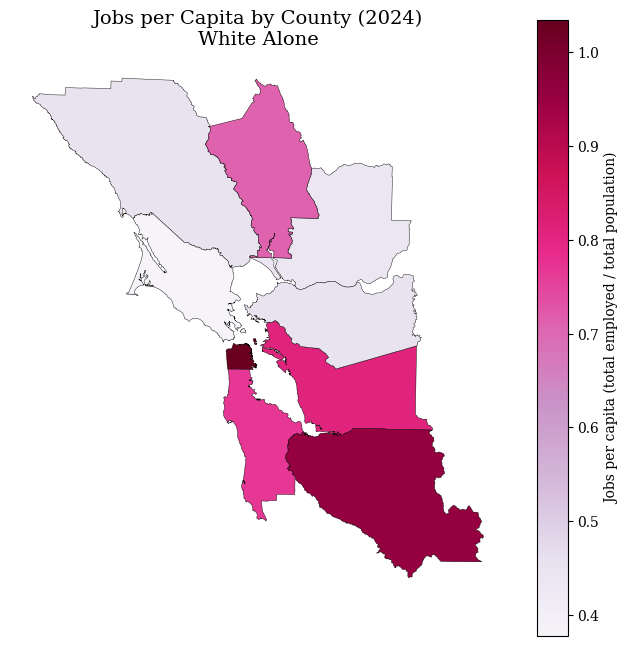

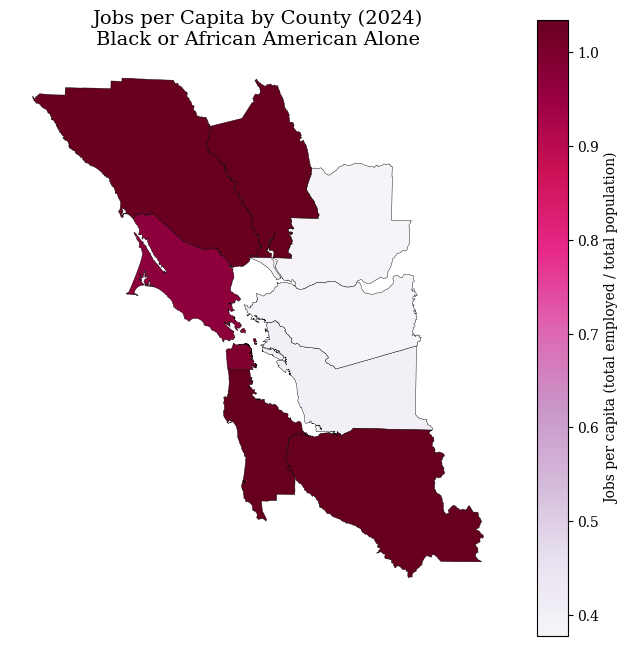

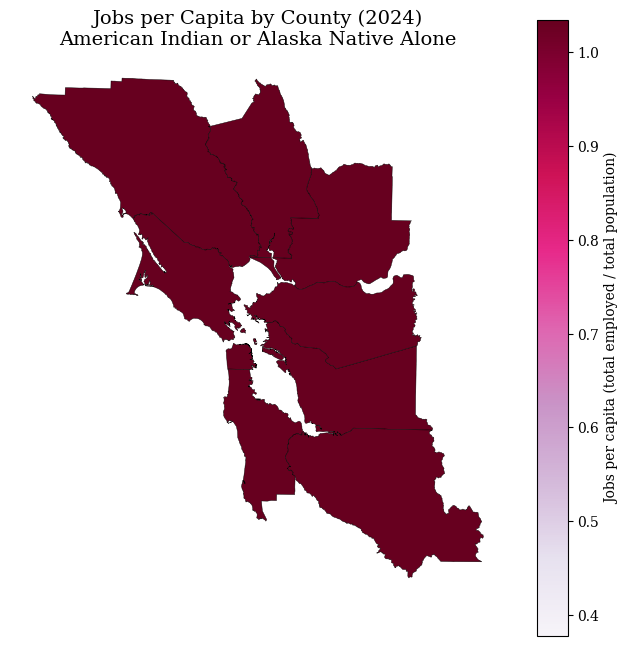

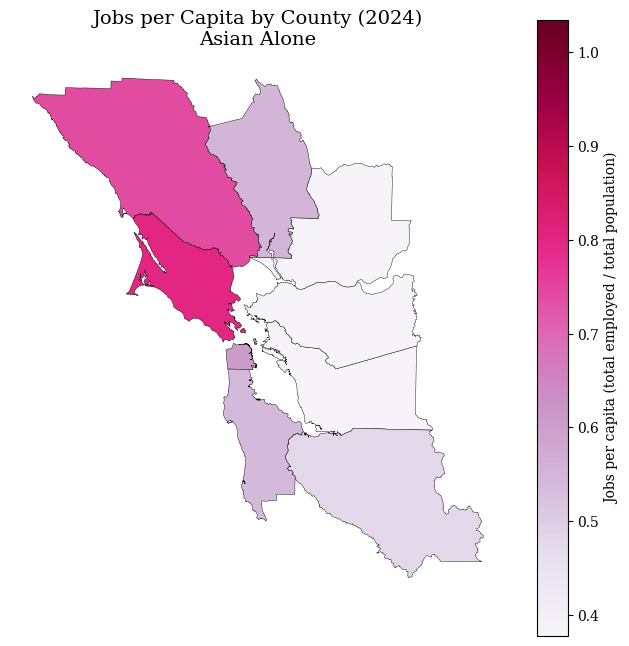

In [121]:
import matplotlib.pyplot as plt
# sets font to Serif for consistency for ArcGIS story map - Serif looks closer to Times New Roman
plt.rcParams["font.family"] = "serif"
for race in map_race_df["race_label_value"].unique():

    race_df = map_race_df[map_race_df["race_label_value"] == race].copy()

    race_gdf = gdf.merge(
        race_df[["county", "jobs_per_capita"]],
        left_on="CountyName",
        right_on="county",
        how="left"
    )

    race_gdf = race_gdf[race_gdf["jobs_per_capita"].notna()].copy()
    race_gdf["jobs_per_capita"] = pd.to_numeric( # convert to numeric
        race_gdf["jobs_per_capita"],
        errors="coerce"
    ).round(2)
    race_gdf = race_gdf.to_crs("EPSG:3310")

    fig, ax = plt.subplots(figsize=(8, 8))

    race_gdf.plot(
        column="jobs_per_capita",
        cmap="PuRd", #PiYG
        vmin=white_vmin, # benchmark for coloring
        vmax=white_vmax,
        legend_kwds={"label": "Jobs per capita (total employed / total population)"}, # we decide not to use natural_breaks due to readability
        legend=True,
        edgecolor="black",
        linewidth=0.3,
        ax=ax
    )

    ax.set_title(f"Jobs per Capita by County (2024)\n{race}", fontsize=14)
    ax.axis("off")

    plt.savefig(
        f"visualizations/jobs_per_capita_map_2024_{race.replace(' ', '_')}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [122]:
###### SECTION 5 ########

# JOBS PER CAPITA BY ETHNICITY BY COUNTY

df_ethnicity = county_df[
    (county_df["industry"] == "00") & # all industries filtered
    (county_df["race"] == "A0") & # this time race is not filtered to all as we are interested in this variable now
    (county_df["ownercode"] == "A05") &
    (county_df["firmsize"] == 0) &
    (county_df["ethnicity"] != "A0")  #this time ethnicity is not filtered yet
].copy()

In [123]:
df_ethnicity.head()

,geo_level,geo_level_label_value,geography,geography_label_value,ind_level,industry,industry_label_value,ownercode,ownercode_label_value,race,race_label_value,ethnicity,ethnicity_label_value,firmsize,firmsize_label_value,agg_level,year_pd,n_employed
1,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A0,All Races,A1,Not Hispanic or Latino,0,All Firm Sizes,4137,2018-01-01,472770.0
2,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A0,All Races,A2,Hispanic or Latino,0,All Firm Sizes,4137,2018-01-01,151416.0
2437,C,Counties,6013,"Contra Costa, CA",A,00,All NAICS Sectors,A05,All Private,A0,All Races,A1,Not Hispanic or Latino,0,All Firm Sizes,4137,2018-01-01,223871.0
2438,C,Counties,6013,"Contra Costa, CA",A,00,All NAICS Sectors,A05,All Private,A0,All Races,A2,Hispanic or Latino,0,All Firm Sizes,4137,2018-01-01,74672.0
4873,C,Counties,6041,"Marin, CA",A,00,All NAICS Sectors,A05,All Private,A0,All Races,A1,Not Hispanic or Latino,0,All Firm Sizes,4137,2018-01-01,66228.0


In [124]:
# check ethnicity names so to check they are all there
df_ethnicity[["ethnicity", "ethnicity_label_value"]].drop_duplicates().sort_values("ethnicity")

,ethnicity,ethnicity_label_value
1,A1,Not Hispanic or Latino
2,A2,Hispanic or Latino


In [125]:
# transform year in datetime. we know this is not necessary but we keeep it consistent as it might be useful in the future
df_ethnicity["year_pd"] = pd.to_datetime(df_ethnicity["year_pd"])

In [126]:
# drop missing employment before grouping
df_ethnicity = df_ethnicity.dropna(subset=["n_employed"])

In [127]:
# adjust county names from San Francisco, CA to San Francisco to mantain consistency
df_ethnicity["county"] = df_ethnicity["geography_label_value"].str.replace(", CA", "", regex=False)

In [128]:
# merge df_race with acs_all_df so to calculate jobs per capita
df_ethnicity = df_ethnicity.merge(
    acs_all_df,
    on=["county", "year_pd"],
    how="left"
)

df_ethnicity.head()

,geo_level,geo_level_label_value,geography,geography_label_value,ind_level,industry,industry_label_value,ownercode,ownercode_label_value,race,...,agg_level,year_pd,n_employed,county,pop_total,pop_white,pop_black,pop_native,pop_asian,pop_hispanic
0,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A0,...,4137,2018-01-01,472770.0,Alameda,1643700,523391,172329,5288,483067,369061
1,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A0,...,4137,2018-01-01,151416.0,Alameda,1643700,523391,172329,5288,483067,369061
2,C,Counties,6013,"Contra Costa, CA",A,00,All NAICS Sectors,A05,All Private,A0,...,4137,2018-01-01,223871.0,Contra Costa,1133247,502951,93683,2376,182135,288101
3,C,Counties,6013,"Contra Costa, CA",A,00,All NAICS Sectors,A05,All Private,A0,...,4137,2018-01-01,74672.0,Contra Costa,1133247,502951,93683,2376,182135,288101
4,C,Counties,6041,"Marin, CA",A,00,All NAICS Sectors,A05,All Private,A0,...,4137,2018-01-01,66228.0,Marin,260295,185809,5597,435,14815,41335


In [129]:
# using the function 6

ethnicity_map = {
    "A2":"pop_hispanic",
    "A1":"pop_total"
}

df_ethnicity = map_ethnicity_population(df_ethnicity, ethnicity_map=ethnicity_map)

In [130]:
df_ethnicity.head()

,geo_level,geo_level_label_value,geography,geography_label_value,ind_level,industry,industry_label_value,ownercode,ownercode_label_value,race,...,year_pd,n_employed,county,pop_total,pop_white,pop_black,pop_native,pop_asian,pop_hispanic,population_by_ethnicity
0,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A0,...,2018-01-01,472770.0,Alameda,1643700,523391,172329,5288,483067,369061,1643700
1,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A0,...,2018-01-01,151416.0,Alameda,1643700,523391,172329,5288,483067,369061,369061
2,C,Counties,6013,"Contra Costa, CA",A,00,All NAICS Sectors,A05,All Private,A0,...,2018-01-01,223871.0,Contra Costa,1133247,502951,93683,2376,182135,288101,1133247
3,C,Counties,6013,"Contra Costa, CA",A,00,All NAICS Sectors,A05,All Private,A0,...,2018-01-01,74672.0,Contra Costa,1133247,502951,93683,2376,182135,288101,288101
4,C,Counties,6041,"Marin, CA",A,00,All NAICS Sectors,A05,All Private,A0,...,2018-01-01,66228.0,Marin,260295,185809,5597,435,14815,41335,260295


In [131]:
df_ethnicity = df_ethnicity[df_ethnicity["population_by_ethnicity"].notna()]

In [132]:
df_ethnicity.head()

,geo_level,geo_level_label_value,geography,geography_label_value,ind_level,industry,industry_label_value,ownercode,ownercode_label_value,race,...,year_pd,n_employed,county,pop_total,pop_white,pop_black,pop_native,pop_asian,pop_hispanic,population_by_ethnicity
0,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A0,...,2018-01-01,472770.0,Alameda,1643700,523391,172329,5288,483067,369061,1643700
1,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A0,...,2018-01-01,151416.0,Alameda,1643700,523391,172329,5288,483067,369061,369061
2,C,Counties,6013,"Contra Costa, CA",A,00,All NAICS Sectors,A05,All Private,A0,...,2018-01-01,223871.0,Contra Costa,1133247,502951,93683,2376,182135,288101,1133247
3,C,Counties,6013,"Contra Costa, CA",A,00,All NAICS Sectors,A05,All Private,A0,...,2018-01-01,74672.0,Contra Costa,1133247,502951,93683,2376,182135,288101,288101
4,C,Counties,6041,"Marin, CA",A,00,All NAICS Sectors,A05,All Private,A0,...,2018-01-01,66228.0,Marin,260295,185809,5597,435,14815,41335,260295


In [133]:
# let's build the recovery index also for ethnicity/hispanic population
df_ethnicity = add_baseline(
    df_ethnicity,
    value_col="n_employed",
    baseline_year=2019,
    group_cols=["county", "ethnicity"],
    baseline_col="baseline_emp_ethnicity"
)

In [134]:
# let's build the recovery index also for ethnicity
#baseline_ethnicity = df_ethnicity[
#    df_ethnicity["year_pd"].dt.year == 2019
#][["county", "ethnicity", "n_employed"]].rename(
#    columns={"n_employed": "baseline_emp_ethnicity"}
#)

In [135]:
#df_ethnicity = df_ethnicity.merge(
#    baseline_ethnicity,
#    on=["county", "ethnicity"],
#    how="left"
#)

In [136]:
# recovery index calculation for ethnicity using Function 2
df_ethnicity = add_recovery_index(
    df_ethnicity,
    current_col="n_employed",
    baseline_col="baseline_emp_ethnicity",
    recovery_col="recovery_index_ethnicity"
)

In [137]:
# let's drop any missing population_by_ethnicity before computing jobs per capita
# we create a new df because otherwise we would lose data for future work (original is df_ethnicity)
df_ethnicity_plot = df_ethnicity.dropna(subset=["population_by_ethnicity"])

In [138]:
df_ethnicity_plot[[
    "county", "ethnicity", "ethnicity_label_value",
    "pop_hispanic", "population_by_ethnicity", "n_employed"
]].head(15)

,county,ethnicity,ethnicity_label_value,pop_hispanic,population_by_ethnicity,n_employed
0,Alameda,A1,Not Hispanic or Latino,369061,1643700,472770.0
1,Alameda,A2,Hispanic or Latino,369061,369061,151416.0
2,Contra Costa,A1,Not Hispanic or Latino,288101,1133247,223871.0
3,Contra Costa,A2,Hispanic or Latino,288101,288101,74672.0
4,Marin,A1,Not Hispanic or Latino,41335,260295,66228.0
5,Marin,A2,Hispanic or Latino,41335,41335,19487.0
6,Napa,A1,Not Hispanic or Latino,47687,140530,36361.0
7,Napa,A2,Hispanic or Latino,47687,47687,19297.0
8,San Francisco,A1,Not Hispanic or Latino,132651,870044,465885.0
9,San Francisco,A2,Hispanic or Latino,132651,132651,95726.0


In [139]:
#calculate jobs_per_capita with the races available
df_ethnicity_plot["jobs_per_capita"] = df_ethnicity["n_employed"] / df_ethnicity["population_by_ethnicity"]

In [140]:
# looks good we can save it in "processed" we will change year into datetime later

df_ethnicity_plot.to_csv("data/processed/df_ethnicity_plot.csv", index=False)

In [141]:
# we want to do a choropleth map by race in 2024 to show differences in jobs per capita by county
map_ethnicity_df = df_ethnicity_plot[df_ethnicity_plot["year_pd"].dt.year == 2024].copy()

In [142]:
map_ethnicity_df.head()

,geo_level,geo_level_label_value,geography,geography_label_value,ind_level,industry,industry_label_value,ownercode,ownercode_label_value,race,...,pop_total,pop_white,pop_black,pop_native,pop_asian,pop_hispanic,population_by_ethnicity,baseline_emp_ethnicity,recovery_index_ethnicity,jobs_per_capita
108,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A0,...,1649473,452099,154136,3417,539370,386114,1649473,476774.0,101.196374,0.292504
109,C,Counties,6001,"Alameda, CA",A,00,All NAICS Sectors,A05,All Private,A0,...,1649473,452099,154136,3417,539370,386114,386114,156843.0,110.346652,0.448238
110,C,Counties,6013,"Contra Costa, CA",A,00,All NAICS Sectors,A05,All Private,A0,...,1165012,443990,92564,1832,217115,321749,1165012,224936.0,98.293292,0.189781
111,C,Counties,6013,"Contra Costa, CA",A,00,All NAICS Sectors,A05,All Private,A0,...,1165012,443990,92564,1832,217115,321749,321749,76971.0,111.341934,0.26636
112,C,Counties,6041,"Marin, CA",A,00,All NAICS Sectors,A05,All Private,A0,...,257969,167816,5379,166,15705,50216,257969,65803.0,98.597328,0.251503


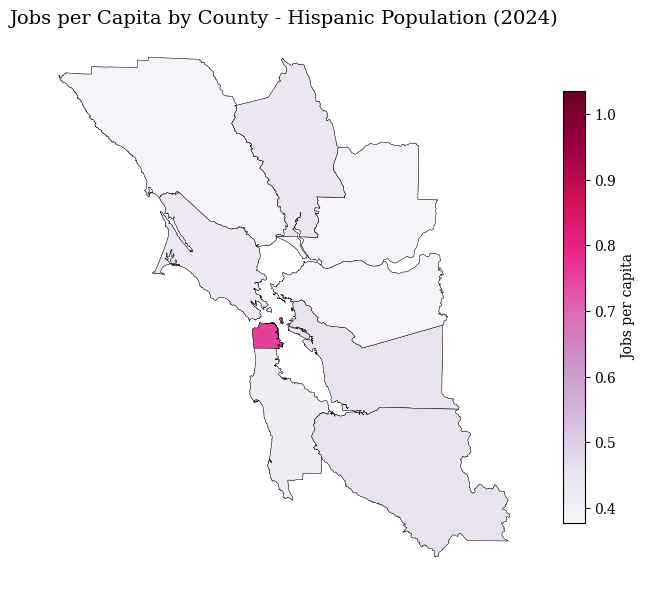

In [145]:
import matplotlib.pyplot as plt
import pandas as pd
# sets font to Serif for consistency for ArcGIS story map - Serif looks closer to Times New Roman
plt.rcParams["font.family"] = "serif"
# Keeps only rows with valid jobs_per_capita
ethnicity_df = map_ethnicity_df[
    map_ethnicity_df["jobs_per_capita"].notna()
].copy()
ethnicity_df["jobs_per_capita"] = pd.to_numeric(
    ethnicity_df["jobs_per_capita"],
    errors="coerce"
).round(2)

ethnicity_df = ethnicity_df[
    ethnicity_df["jobs_per_capita"].notna()
].copy()
# Merges county geometries with jobs per capita data
ethnicity_gdf = gdf.merge(
    ethnicity_df[["county", "jobs_per_capita"]],
    left_on="CountyName",
    right_on="county",
    how="left"
)
ethnicity_gdf = ethnicity_gdf[
    ethnicity_gdf["jobs_per_capita"].notna()
].copy()
ethnicity_gdf = ethnicity_gdf.to_crs("EPSG:3310")
fig, ax = plt.subplots(figsize=(8, 8))
ethnicity_gdf.plot(
    column="jobs_per_capita",
    cmap="PuRd",
    vmin=white_vmin,
    vmax=white_vmax,
    legend=True,
    legend_kwds={
        "label": "Jobs per capita",
        "shrink": 0.7
    },
    edgecolor="black",
    linewidth=0.3,
    ax=ax
)
ax.set_title(
    "Jobs per Capita by County - Hispanic Population (2024)",
    fontsize=14
)
ax.axis("off")
plt.savefig(
    "visualizations/jobs_per_capita_map_2024_ethnicity.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
# we want to create a requirements document so to run this regardless of the computer used

with open("requirements.txt", "w") as f:
    f.write("""pandas
numpy
matplotlib
geopandas
shapely
fiona
pyproj
""")

In [ ]:
from google.colab import files
files.download("requirements.txt")